In [38]:
!pip install pyvis igraph spacy python-louvain spacytextblob
# Download the Spanish model
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 46.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [53]:
import os
import re
import json
import math
import sys
import gc
import csv
import unicodedata
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
import networkx as nx
from networkx.algorithms import community as nx_comm
import plotly.express as px
import plotly.graph_objects as go
from pyvis.network import Network
import igraph as ig
import spacy
import warnings
warnings.filterwarnings("ignore")
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD, NMF
from sklearn.preprocessing import normalize
from IPython.display import display
from spacytextblob.spacytextblob import SpacyTextBlob
from textblob import TextBlob
import community as community_louvain

## Preparar la data y envs

Para nuestro laboratorio decidimos utilizar "tioberny.txt" y a continuacion cargaremos la data, la pasaremos un csv y posteriormete la vamos a limpiar. Para ellos vamos a descartar algunas columnas que no sean relevantes para el analisis de redes ni exploratorio.

Las columnas seleccionadas se organizan en categorías para el análisis. Los identificadores de tweet y usuario junto con fechas y URLs proporcionan la estructura básica de datos. Las métricas de usuario como followers_count, friends_count y statuses_count revelan el perfil y actividad de cada cuenta, mientras que verified y blue indican estatus especial que puede influir en el alcance. El contenido textual raw_content es fundamental para análisis de sentimientos y procesamiento de lenguaje natural, complementado por hashtags y cashtags que muestran temas y tendencias. Las métricas de engagement como reply_count, retweet_count y like_count miden la interacción y popularidad del contenido. Los campos in_reply_to capturan conversaciones y hilos, esenciales para análisis de redes sociales y patrones de comunicación. Los mentioned_users identifican conexiones entre usuarios, crucial para mapear redes de interacción. Finalmente, retweeted_tweet y quoted_tweet preservan la estructura viral del contenido, permitiendo rastrear la propagación de información y detectar contenido influyente en la red.

In [40]:
DATA_DIR = "data/"
DATA_FILE = DATA_DIR + "tioberny.txt"
DATA_CLEAN = DATA_DIR + "clean_tioberny.csv"

def processTiobernyToCsv(input_path=DATA_FILE, output_path=DATA_CLEAN):
    enc = "utf-8"
    with open(input_path, "rb") as fb:
        sig = fb.read(4)
    if sig.startswith(b"\xff\xfe") or sig.startswith(b"\xfe\xff"):
        enc = "utf-16"
    elif sig.startswith(b"\xef\xbb\xbf"):
        enc = "utf-8-sig"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cols = [
        "tweet_id","tweet_id_str","date","url",
        "user_id","user_id_str","username","displayname",
        "followers_count","friends_count","statuses_count","favourites_count",
        "listed_count","location","protected","verified","blue","user_description","lang",
        "raw_content","reply_count","retweet_count","like_count","quote_count",
        "conversation_id","conversation_id_str","hashtags","cashtags",
        "mentioned_users","mentioned_users_ids","mentioned_users_displaynames",
        "links","view_count","retweeted_tweet","quoted_tweet",
        "in_reply_to_tweet_id","in_reply_to_tweet_id_str",
        "in_reply_to_user_id","in_reply_to_user_id_str","in_reply_to_username","in_reply_to_displayname"
    ]
    def extract_users(mus, field):
        if not isinstance(mus, list):
            return ""
        out=[]
        for u in mus:
            if isinstance(u, dict):
                v=u.get(field)
                if v: out.append(str(v))
        return ",".join(out)
    def serialize_obj(obj):
        if obj is None: return pd.NA
        if isinstance(obj,(dict,list)): return json.dumps(obj,ensure_ascii=False)
        return str(obj)
    rows=[]
    with open(input_path,"r",encoding=enc) as f_in:
        for line in f_in:
            line=line.strip()
            if not line: continue
            try: tw=json.loads(line)
            except: continue
            user=tw.get("user") or {}
            in_reply_user=tw.get("inReplyToUser") or {}
            row={
                "tweet_id":tw.get("id"),
                "tweet_id_str":tw.get("id_str"),
                "date":tw.get("date"),
                "url":tw.get("url"),
                "user_id":user.get("id"),
                "user_id_str":user.get("id_str"),
                "username":user.get("username"),
                "displayname":user.get("displayname"),
                "followers_count":user.get("followersCount"),
                "friends_count":user.get("friendsCount"),
                "statuses_count":user.get("statusesCount"),
                "favourites_count":user.get("favouritesCount"),
                "listed_count":user.get("listedCount"),
                "location":user.get("location"),
                "protected":user.get("protected"),
                "verified":user.get("verified"),
                "blue":user.get("blue"),
                "user_description":user.get("rawDescription"),
                "lang":tw.get("lang"),
                "raw_content":tw.get("rawContent"),
                "reply_count":tw.get("replyCount"),
                "retweet_count":tw.get("retweetCount"),
                "like_count":tw.get("likeCount"),
                "quote_count":tw.get("quoteCount"),
                "conversation_id":tw.get("conversationId"),
                "conversation_id_str":tw.get("conversationIdStr"),
                "hashtags":",".join(tw.get("hashtags") or []),
                "cashtags":",".join(tw.get("cashtags") or []),
                "mentioned_users":extract_users(tw.get("mentionedUsers"),"username"),
                "mentioned_users_ids":extract_users(tw.get("mentionedUsers"),"id"),
                "mentioned_users_displaynames":extract_users(tw.get("mentionedUsers"),"displayname"),
                "links":",".join([str(link) for link in tw.get("links") or []]),
                "view_count":tw.get("viewCount"),
                "retweeted_tweet":serialize_obj(tw.get("retweetedTweet")),
                "quoted_tweet":serialize_obj(tw.get("quotedTweet")),
                "in_reply_to_tweet_id":tw.get("inReplyToTweetId"),
                "in_reply_to_tweet_id_str":tw.get("inReplyToTweetIdStr"),
                "in_reply_to_user_id":in_reply_user.get("id"),
                "in_reply_to_user_id_str":in_reply_user.get("id_str"),
                "in_reply_to_username":in_reply_user.get("username"),
                "in_reply_to_displayname":in_reply_user.get("displayname")
            }
            for k,v in row.items():
                if v is None: row[k]=pd.NA
            rows.append(row)
    df=pd.DataFrame(rows,columns=cols)
    df.to_csv(output_path,index=False,encoding="utf-8",na_rep="null")
    return {"output_csv":output_path,"rows":len(df)}

processTiobernyToCsv()

{'output_csv': 'data/clean_tioberny.csv', 'rows': 5019}

In [41]:
DATA_CLEAN     = "data/clean_tioberny.csv"
DATA_CLEAN_OUT = "data/clean_tioberny_v2.csv"
DATA_USE       = "data/clean_tioberny_v3.csv"

URL_RE   = re.compile(r"https://\S+")
EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u26FF]+")


nlp = spacy.load("es_core_news_sm")
STOP_ES = nlp.Defaults.stop_words

def normalizeText(s: str) -> str:
    if pd.isna(s):
        return s
    s = str(s).lower()
    s = s.replace("\n", " ").replace("\r", " ")
    s = URL_RE.sub(" ", s)
    s = EMOJI_RE.sub(" ", s)
    s = s.replace("@", " ").replace("#", " ")
    s = ''.join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenizeKeepNumbers(text: str):
    doc = nlp(text)
    return [tok.text for tok in doc if tok.is_alpha or tok.like_num]

def lemmatizeKeepNumbers(text: str):
    doc = nlp(text)
    return [tok.lemma_ for tok in doc if (tok.is_alpha or tok.like_num) and tok.lemma_ not in STOP_ES]

def processSection2():
    df = pd.read_csv(DATA_CLEAN)
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(normalizeText)
    df.to_csv(DATA_CLEAN_OUT, index=False, encoding="utf-8")
    df['exclaim_count']  = df['raw_content'].str.count(r"[!¡]")
    df['question_count'] = df['raw_content'].str.count(r"[?¿]")
    df['tokens'] = df['raw_content'].apply(tokenizeKeepNumbers)
    df['lemmas'] = df['raw_content'].apply(lemmatizeKeepNumbers)
    df.drop_duplicates(subset=["tweet_id"], inplace=True)
    df['username'] = df['username'].str.lower()
    df['mentioned_users'] = df['mentioned_users'].str.lower()
    df.to_csv(DATA_USE, index=False, encoding="utf-8")
    return df

df_section2 = processSection2()

## Analisis Exploratorio

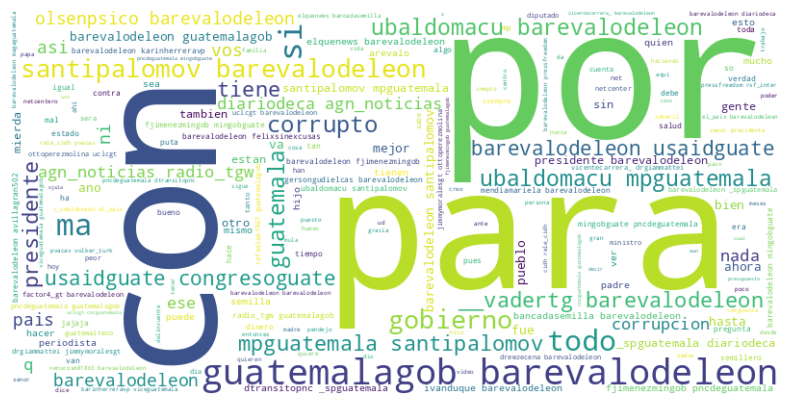

Número de tweets: 4944
Número de usuarios únicos: 2620
Número total de menciones: 17242
Top 10 hashtags: [('guatemalasaleadelante', 24), ('urgente', 17), ('minfinsaleadelante', 17), ('guatemala', 15), ('presupuesto2025', 14), ('unpresupuestoparalapoblacion', 13), ('enelpaisdca', 12), ('nacionalesagn', 8), ('traficogt', 6), ('ahora', 6)]
Top 10 usuarios con más interacciones:
 username
jmilei           113363
arteymas_         72607
amazlngnature     66110
pablocasx1        42645
nayibbukele       40917
petrogustavo      22552
monerorictus      12421
agustinromm       11905
danteforesi       11304
captercio         10992
dtype: int64
Número de tweets repetidos: 204


In [42]:
df = pd.read_csv("data/clean_tioberny_v3.csv")

num_tweets = len(df)
num_usuarios = df["username"].nunique()
num_menciones = df["mentioned_users"].str.count(",").sum() + df["mentioned_users"].notna().sum()

hashtags = []
df["hashtags"].dropna().apply(lambda x: hashtags.extend(x.split(",")))
conteo_hashtags = Counter([h for h in hashtags if h != ""])
top_hashtags = conteo_hashtags.most_common(10)

interacciones = (
    df.groupby("username")[["reply_count","retweet_count","like_count","quote_count"]]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
)

repetidos = df["raw_content"].duplicated().sum()

omitidas = {
    "y","que","lo","la","e","de","no","el","a","los","en",
    "las","un","una","unos","unas","al","del",
    "se","me","te","nos","le","les",
    "mi","mis","tu","tus","su","sus","nuestro","nuestra","nuestros","nuestras",
    "o","u","pero","sino","porque","como","cuando","donde",
    "ya","muy","más","menos","también","aún","sí","solo","solamente",
    "este","esta","estos","estas","eso","esa","esos","esas","aquella","aquellos","aquellas",
    "él","ella","ellos","ellas","yo","tú","usted","ustedes","nosotros","nosotras",
    "ser","estar","haber","hay","son","es"
}
texto = " ".join(str(t) for t in df["raw_content"].dropna())
wc = WordCloud(width=800, height=400, background_color="white", stopwords=omitidas).generate(texto)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

print("Número de tweets:", num_tweets)
print("Número de usuarios únicos:", num_usuarios)
print("Número total de menciones:", int(num_menciones))
print("Top 10 hashtags:", top_hashtags)
print("Top 10 usuarios con más interacciones:\n", interacciones)
print("Número de tweets repetidos:", repetidos)


Para el wordcloud se omitieron una lista de palabras, que en resumen son: Artículos, preposiciones, conjunciones, pronombres y adverbios muy frecuentes esto con el fin de omitir palabras comunes y que no aportan valor al analisis exploratorio.

## Preguntas

¿Qué usuarios generan más interacciones?

¿Qué hashtags son los más utilizados?

¿Existe mucha repetición de contenido en los tweets?


## Topología de la Red

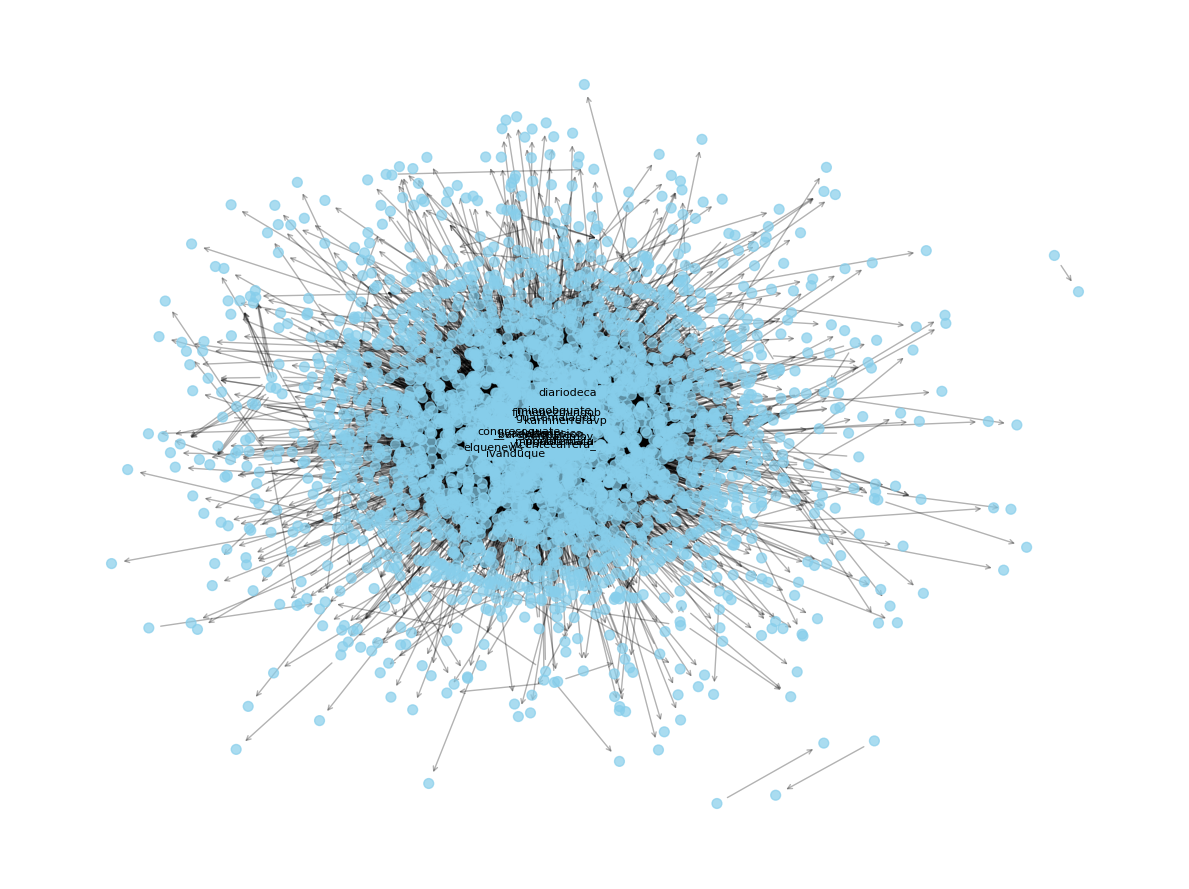

{'nodes': 3104,
 'edges': 12246,
 'density': 0.0012714250592210398,
 'diameter': 6,
 'avg_clustering': 0.3729830122015358,
 'top_in_degree': [('barevalodeleon', 5506),
  ('guatemalagob', 1113),
  ('ubaldomacu', 1024),
  ('fjimenezmingob', 583),
  ('santipalomov', 528),
  ('mpguatemala', 467),
  ('__vadertg', 441),
  ('olsenpsico', 342),
  ('elquenews', 338),
  ('vicentecarrera_', 305)],
 'top_out_degree': [('elrevoltijogt', 223),
  ('alejand09098718', 140),
  ('ialmgg', 118),
  ('benitoc67601310', 103),
  ('leraovalle', 101),
  ('salquevedo', 93),
  ('mendiamariela', 88),
  ('billyc2023', 86),
  ('johanmauricio34', 84),
  ('gilrey422483', 81)],
 'top_pagerank': [('barevalodeleon', 0.20290552505571693),
  ('guatemalagob', 0.03233903527513463),
  ('ubaldomacu', 0.01651850818124156),
  ('usaidguate', 0.01265363911869081),
  ('santipalomov', 0.01042214481924274),
  ('ivanduque', 0.010065396804320954),
  ('mpguatemala', 0.009702452003924588),
  ('olsenpsico', 0.008720159665475053),
  ('maga

In [43]:
DATA_USE = "data/clean_tioberny_v3.csv"
GEXF_OUT = "data/graph_tioberny.gexf"
PLOT_OUT = "data/graph_tioberny.png"

df = pd.read_csv(DATA_USE)

def extract_retweeted_username(rt):
    if pd.isna(rt):
        return None
    try:
        if isinstance(rt, str):
            obj = json.loads(rt)
        else:
            obj = rt
        if isinstance(obj, dict):
            u = obj.get("user") or {}
            return u.get("username") or obj.get("username") or None
    except Exception:
        try:
            s = str(rt)
            if '"username"' in s:
                import re
                m = re.search(r'"username"\s*:\s*"([^"]+)"', s)
                if m:
                    return m.group(1)
        except Exception:
            return None
    return None

G = nx.DiGraph()

for _, row in df.iterrows():
    src = row.get("username")
    if pd.isna(src):
        continue
    src = str(src).lower()
    mentioned = row.get("mentioned_users")
    if pd.notna(mentioned) and str(mentioned).strip() != "":
        for tgt in str(mentioned).split(","):
            tgt = tgt.strip().lower()
            if tgt == "" or tgt == src:
                continue
            if not G.has_node(src): G.add_node(src)
            if not G.has_node(tgt): G.add_node(tgt)
            if G.has_edge(src, tgt):
                G[src][tgt]["weight"] += 1
                G[src][tgt]["mentions"] += 1
            else:
                G.add_edge(src, tgt, weight=1, mentions=1, replies=0, retweets=0)
    in_reply = row.get("in_reply_to_username")
    if pd.notna(in_reply) and str(in_reply).strip() != "":
        tgt = str(in_reply).strip().lower()
        if tgt != "" and tgt != src:
            if not G.has_node(src): G.add_node(src)
            if not G.has_node(tgt): G.add_node(tgt)
            if G.has_edge(src, tgt):
                G[src][tgt]["weight"] += 1
                G[src][tgt]["replies"] += 1
            else:
                G.add_edge(src, tgt, weight=1, mentions=0, replies=1, retweets=0)
    rt_user = extract_retweeted_username(row.get("retweeted_tweet"))
    if rt_user:
        tgt = str(rt_user).lower()
        if tgt != "" and tgt != src:
            if not G.has_node(src): G.add_node(src)
            if not G.has_node(tgt): G.add_node(tgt)
            if G.has_edge(src, tgt):
                G[src][tgt]["weight"] += 1
                G[src][tgt]["retweets"] += 1
            else:
                G.add_edge(src, tgt, weight=1, mentions=0, replies=0, retweets=1)

nx.write_gexf(G, GEXF_OUT)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

if num_nodes > 0 and num_edges > 0:
    ug = G.to_undirected()
    if nx.is_connected(ug):
        diameter = nx.diameter(ug)
    else:
        components = sorted(nx.connected_components(ug), key=len, reverse=True)
        largest = ug.subgraph(components[0]).copy()
        diameter = nx.diameter(largest)
else:
    diameter = None

if G.number_of_nodes() > 0:
    ug_for_cluster = G.to_undirected()
    avg_clustering = nx.average_clustering(ug_for_cluster)
else:
    avg_clustering = None

in_deg = dict(G.in_degree(weight="weight"))
out_deg = dict(G.out_degree(weight="weight"))
top_in = Counter(in_deg).most_common(10)
top_out = Counter(out_deg).most_common(10)

pr = nx.pagerank(G, weight="weight") if G.number_of_nodes() > 0 else {}
top_pr = Counter(pr).most_common(10)

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=0.15, iterations=50)
node_size = [max(50, in_deg.get(n,0)+out_deg.get(n,0)) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="skyblue", alpha=0.7)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=8, alpha=0.3)
labels = {n: n for n,deg in sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:15]}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
plt.axis("off")
plt.tight_layout()
plt.show()
plt.savefig(PLOT_OUT, dpi=150)
plt.close()

metrics = {
    "nodes": num_nodes,
    "edges": num_edges,
    "density": density,
    "diameter": diameter,
    "avg_clustering": avg_clustering,
    "top_in_degree": top_in,
    "top_out_degree": top_out,
    "top_pagerank": top_pr
}

metrics

## Identificación de Comunidades

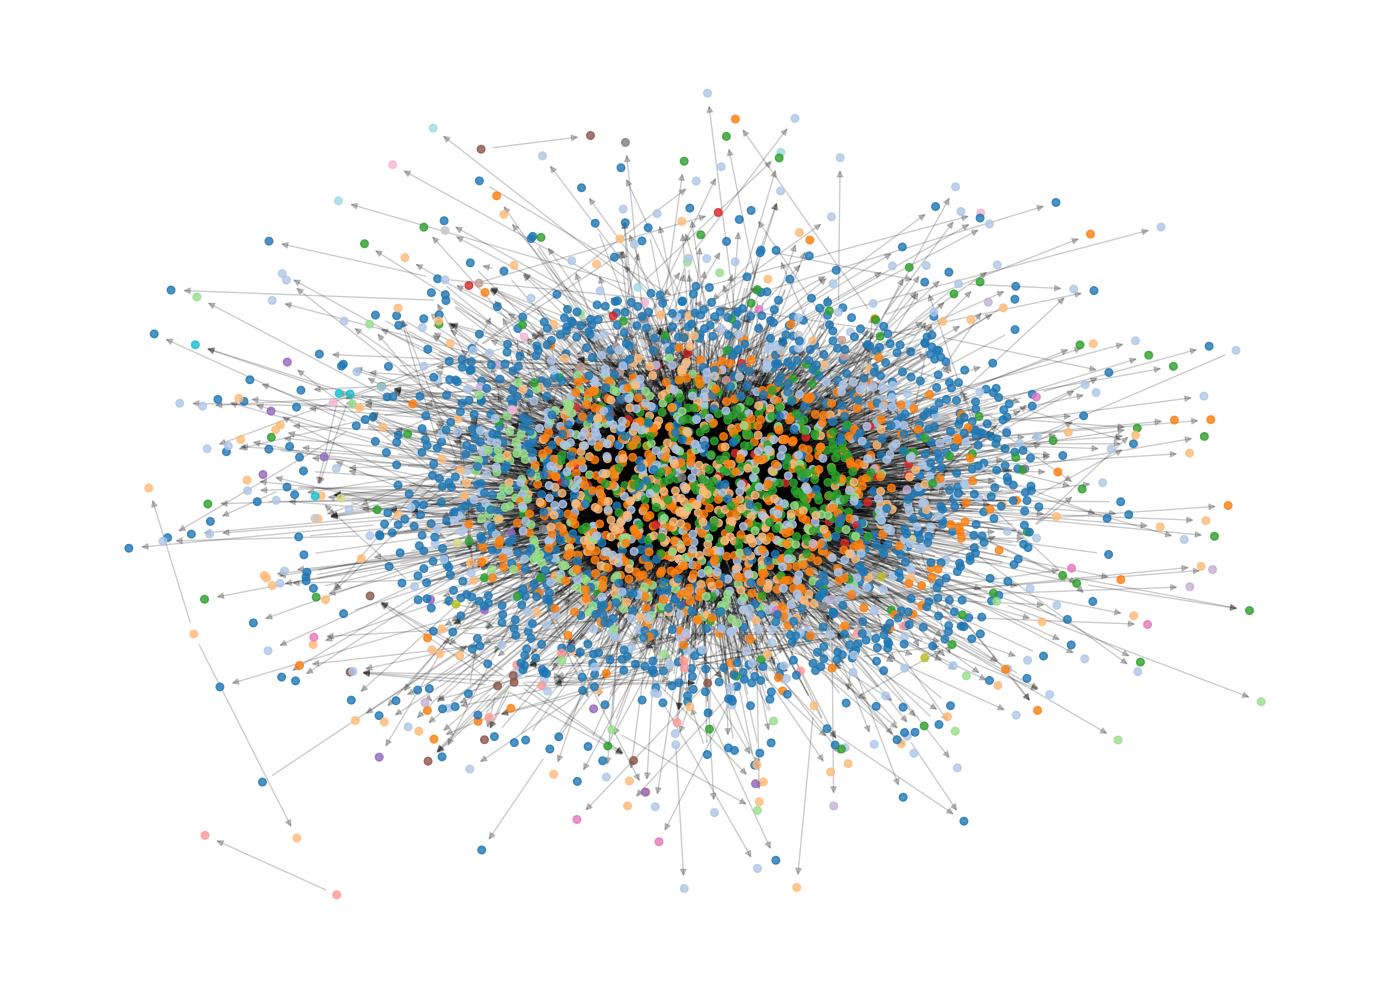

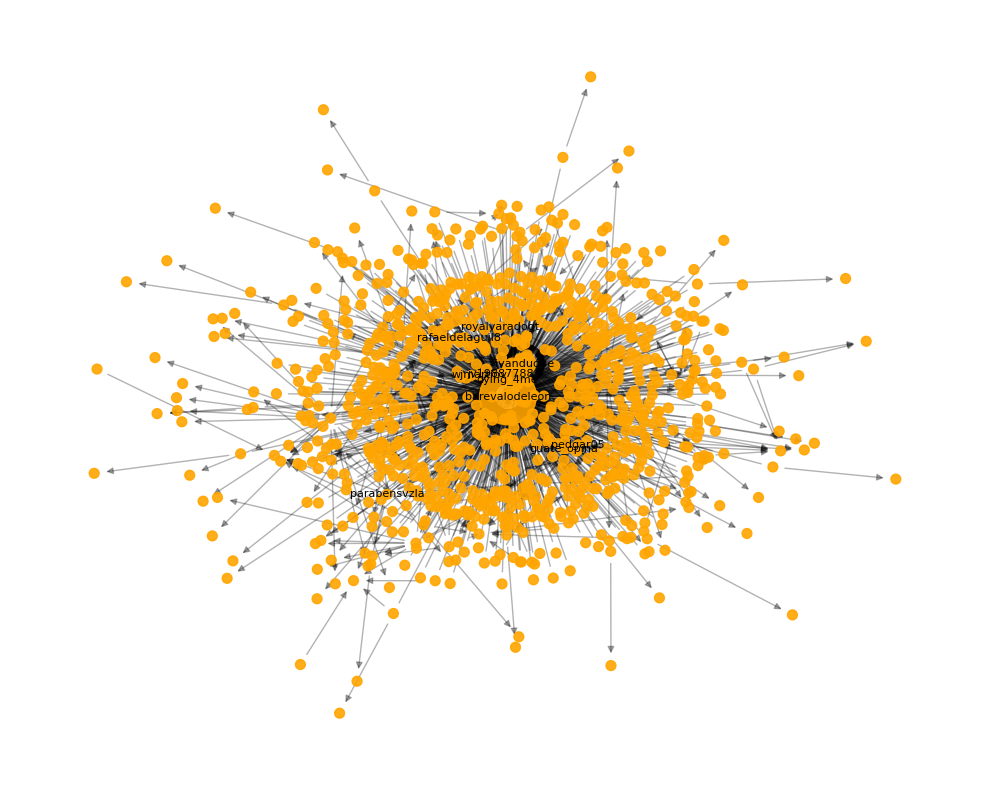

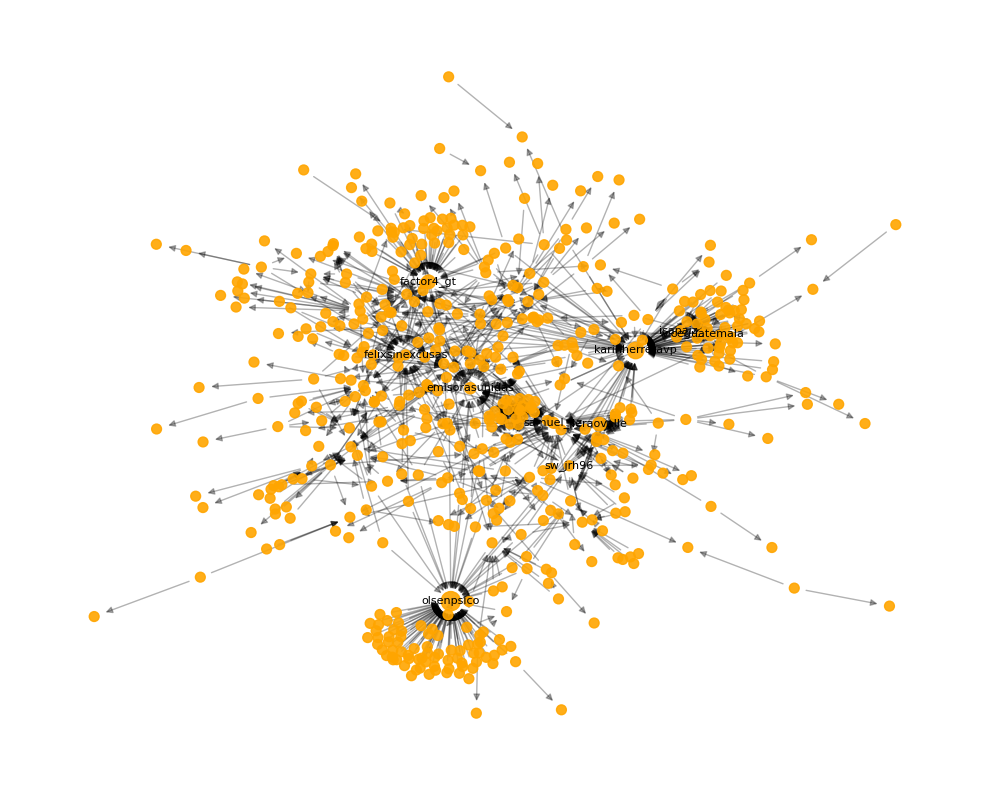

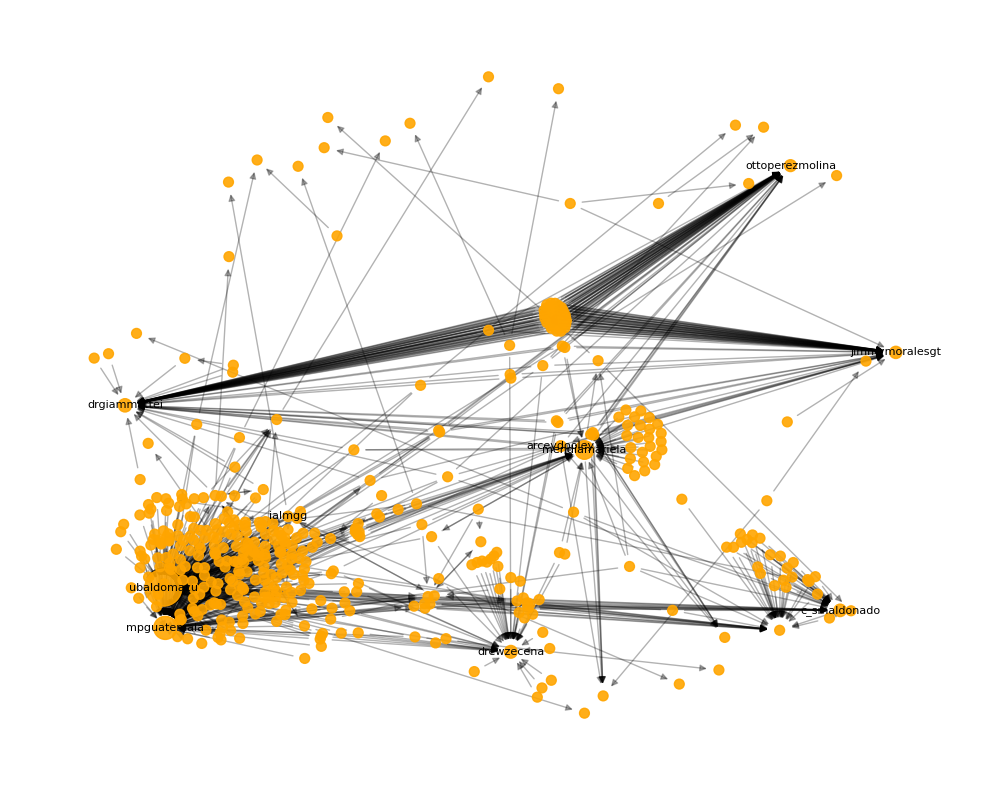

Community Analysis Results:
Total communities found: 31

Top 3 communities by size:
Community 0: 1019 nodes
Community 1: 542 nodes
Community 2: 468 nodes


([(0, 1019, 1436, 2.818449460255152),
  (1, 542, 1078, 3.977859778597786),
  (2, 468, 960, 4.102564102564102),
  (3, 369, 1674, 9.073170731707316),
  (4, 329, 1688, 10.261398176291793),
  (5, 222, 590, 5.315315315315315),
  (6, 34, 61, 3.588235294117647),
  (7, 11, 23, 4.181818181818182),
  (8, 10, 9, 1.8),
  (9, 10, 9, 1.8),
  (10, 9, 18, 4.0),
  (11, 8, 9, 2.25),
  (12, 8, 7, 1.75),
  (13, 6, 6, 2.0),
  (14, 6, 5, 1.6666666666666667),
  (15, 6, 10, 3.3333333333333335),
  (16, 5, 5, 2.0),
  (17, 4, 3, 1.5),
  (18, 4, 5, 2.5),
  (19, 4, 3, 1.5),
  (20, 4, 4, 2.0),
  (21, 4, 3, 1.5),
  (22, 3, 2, 1.3333333333333333),
  (23, 3, 2, 1.3333333333333333),
  (24, 3, 3, 2.0),
  (25, 3, 2, 1.3333333333333333),
  (26, 2, 1, 1.0),
  (27, 2, 1, 1.0),
  (28, 2, 1, 1.0),
  (29, 2, 1, 1.0),
  (30, 2, 1, 1.0)],
 'data/communities_plot.png',
 ['data/community_top1.png',
  'data/community_top2.png',
  'data/community_top3.png'])

In [58]:
DATA_USE = "data/clean_tioberny_v3.csv"
COMM_PLOT_ALL = "data/communities_plot.png"
COMM_PLOT_TOP3 = ["data/community_top1.png","data/community_top2.png","data/community_top3.png"]
GEXF_IN = "data/graph_tioberny.gexf"

G = nx.read_gexf(GEXF_IN)
if G.number_of_nodes() == 0:
    raise SystemExit("empty graph")

ug = G.to_undirected()

# Usar los algoritmos de detección de comunidades de NetworkX
comp = nx_comm.greedy_modularity_communities(ug)
communities = {i: list(c) for i,c in enumerate(sorted(comp, key=len, reverse=True))}

comm_sizes = {k: len(v) for k,v in communities.items()}
top_comms = sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)[:3]

color_map = {}
colors = plt.cm.tab20(range(20))
for i, (cid, nodes) in enumerate(communities.items()):
    c = colors[i % len(colors)]
    for n in nodes:
        color_map[n] = c

pos = nx.spring_layout(G, k=0.15, iterations=50)
plt.figure(figsize=(14,10))
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=[color_map.get(n) for n in G.nodes()], alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.axis("off")
plt.tight_layout()
plt.show()
plt.savefig(COMM_PLOT_ALL, dpi=150)
plt.close()

for idx, (cid, size) in enumerate(top_comms):
    nodes = communities[cid]
    sub = G.subgraph(nodes).copy()
    if sub.number_of_nodes() == 0:
        continue
    sub_pos = nx.spring_layout(sub, k=0.15, iterations=50)
    deg = dict(sub.degree(weight="weight"))
    top_n = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(sub, sub_pos, node_size=[max(50,deg.get(n,0)) for n in sub.nodes()], node_color="orange", alpha=0.9)
    nx.draw_networkx_edges(sub, sub_pos, alpha=0.3)
    labels = {n: n for n,_ in top_n}
    nx.draw_networkx_labels(sub, sub_pos, labels, font_size=8)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.savefig(COMM_PLOT_TOP3[idx], dpi=150)
    plt.close()

community_summary = []
for cid, nodes in sorted(communities.items(), key=lambda x: len(x[1]), reverse=True):
    sub = G.subgraph(nodes)
    edges = sub.number_of_edges()
    avg_deg = sum(dict(sub.degree()).values())/max(1, sub.number_of_nodes())
    community_summary.append((cid, len(nodes), edges, avg_deg))

print("Community Analysis Results:")
print(f"Total communities found: {len(communities)}")
print("\nTop 3 communities by size:")
for i, (cid, size) in enumerate(top_comms):
    print(f"Community {cid}: {size} nodes")

community_summary, COMM_PLOT_ALL, COMM_PLOT_TOP3

## Analisis de influencers y nodos clave

In [49]:
GRAPH_FILE = "data/graph_tioberny_simple.gexf"
DATA_USE = "data/clean_tioberny_v3.csv"
OUT_METRICS = "data/influencers_metrics.csv"

def extract_rt_username(rt):
    if pd.isna(rt):
        return None
    try:
        obj = json.loads(rt) if isinstance(rt, str) else rt
        if isinstance(obj, dict):
            u = obj.get("user") or {}
            return u.get("username") or obj.get("username")
    except Exception:
        s = str(rt)
        m = re.search(r'"username"\s*:\s*"([^"]+)"', s)
        if m:
            return m.group(1)
    return None

G = None
if os.path.exists(GRAPH_FILE):
    try:
        G = nx.read_gexf(GRAPH_FILE)
    except Exception:
        G = None

if G is None:
    df = pd.read_csv(DATA_USE)
    G = nx.DiGraph()
    for _, row in df.iterrows():
        src = row.get("username")
        if pd.isna(src):
            continue
        src = str(src).lower().strip()
        if src == "":
            continue
        if not G.has_node(src):
            G.add_node(src)
        mentioned = row.get("mentioned_users")
        if pd.notna(mentioned) and str(mentioned).strip() != "":
            for tgt in str(mentioned).split(","):
                tgt = tgt.strip().lower()
                if tgt == "" or tgt == src:
                    continue
                if G.has_edge(src, tgt):
                    G[src][tgt]["weight"] = G[src][tgt].get("weight", 0) + 1
                else:
                    G.add_edge(src, tgt, weight=1, type="mention")
        in_reply = row.get("in_reply_to_username")
        if pd.notna(in_reply) and str(in_reply).strip() != "":
            tgt = str(in_reply).strip().lower()
            if tgt != "" and tgt != src:
                if G.has_edge(src, tgt):
                    G[src][tgt]["weight"] = G[src][tgt].get("weight", 0) + 1
                else:
                    G.add_edge(src, tgt, weight=1, type="reply")
        rt_user = extract_rt_username(row.get("retweeted_tweet"))
        if rt_user:
            tgt = str(rt_user).lower().strip()
            if tgt != "" and tgt != src:
                if G.has_edge(src, tgt):
                    G[src][tgt]["weight"] = G[src][tgt].get("weight", 0) + 1
                else:
                    G.add_edge(src, tgt, weight=1, type="retweet")
    try:
        nx.write_gexf(G, GRAPH_FILE)
    except Exception:
        pass

in_deg_w = dict(G.in_degree(weight="weight"))
out_deg_w = dict(G.out_degree(weight="weight"))
total_deg = {n: in_deg_w.get(n, 0) + out_deg_w.get(n, 0) for n in G.nodes()}

deg_centrality = nx.degree_centrality(G)
nodes_count = G.number_of_nodes()

if nodes_count > 1000:
    try:
        betweenness = nx.betweenness_centrality(G, k=200, weight="weight", seed=42)
    except Exception:
        betweenness = nx.betweenness_centrality(G, weight="weight")
else:
    betweenness = nx.betweenness_centrality(G, weight="weight")

try:
    weak_comps = list(nx.weakly_connected_components(G))
    if weak_comps:
        largest = max(weak_comps, key=len)
        sub = G.subgraph(largest).copy()
        closeness_sub = nx.closeness_centrality(sub)
        closeness = {n: closeness_sub.get(n, 0.0) for n in G.nodes()}
    else:
        closeness = {n: 0.0 for n in G.nodes()}
except Exception:
    closeness = nx.closeness_centrality(G)

df_metrics = pd.DataFrame([
    {
        "node": n,
        "in_degree": in_deg_w.get(n, 0),
        "out_degree": out_deg_w.get(n, 0),
        "total_degree": total_deg.get(n, 0),
        "degree_centrality": deg_centrality.get(n, 0.0),
        "betweenness": betweenness.get(n, 0.0),
        "closeness": closeness.get(n, 0.0)
    }
    for n in G.nodes()
])

df_metrics.sort_values("total_degree", ascending=False, inplace=True)
df_metrics.to_csv(OUT_METRICS, index=False)

top_degree = df_metrics.sort_values("total_degree", ascending=False).head(10)
top_in_degree = df_metrics.sort_values("in_degree", ascending=False).head(10)
top_out_degree = df_metrics.sort_values("out_degree", ascending=False).head(10)
top_betweenness = df_metrics.sort_values("betweenness", ascending=False).head(10)
top_closeness = df_metrics.sort_values("closeness", ascending=False).head(10)

print("Top 10 por grado total")
print(top_degree[["node","total_degree"]])
print("\nTop 10 por grado entrante")
print(top_in_degree[["node","in_degree"]])
print("\nTop 10 por grado saliente")
print(top_out_degree[["node","out_degree"]])
print("\nTop 10 por intermediación (betweenness)")
print(top_betweenness[["node","betweenness"]])
print("\nTop 10 por cercanía (closeness)")
print(top_closeness[["node","closeness"]])
print("\nMétricas guardadas en:", OUT_METRICS)

Top 10 por grado total
                node  total_degree
5     barevalodeleon        5506.0
22      guatemalagob        1121.0
65        ubaldomacu        1059.0
66    fjimenezmingob         585.0
222     santipalomov         528.0
150        __vadertg         469.0
60       mpguatemala         468.0
37         elquenews         351.0
333       olsenpsico         343.0
374  vicentecarrera_         334.0

Top 10 por grado entrante
                node  in_degree
5     barevalodeleon     5506.0
22      guatemalagob     1113.0
65        ubaldomacu     1024.0
66    fjimenezmingob      583.0
222     santipalomov      528.0
60       mpguatemala      467.0
150        __vadertg      441.0
333       olsenpsico      342.0
37         elquenews      338.0
374  vicentecarrera_      305.0

Top 10 por grado saliente
                 node  out_degree
347     elrevoltijogt       223.0
760   alejand09098718       140.0
1317           ialmgg       118.0
30    benitoc67601310       103.0
264        lerao

## Detección y análisis de grupos aislados

,component_id,size
0,0,3095
1,1,3
2,2,2
3,3,2
4,4,2
5,5,1
6,6,1
7,7,1
8,8,1
9,9,1


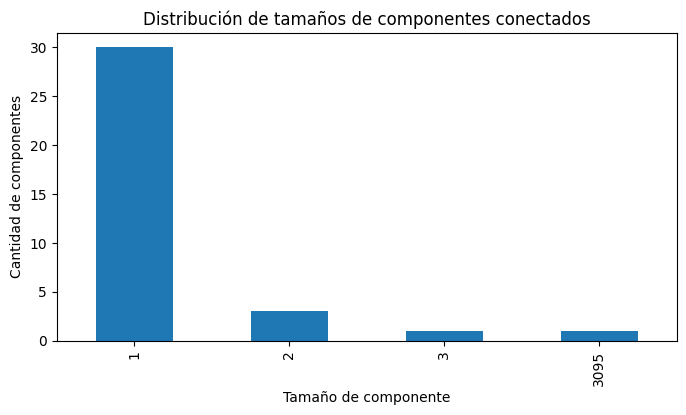

Número de nodos aislados: 30


,component_id,size,edges,density,avg_degree
0,0,3095,12241,0.002530,7.910178
1,1,3,2,0.666667,1.333333
2,2,2,1,1.000000,1.000000
3,3,2,1,1.000000,1.000000
4,4,2,1,1.000000,1.000000
5,5,1,0,0.000000,0.000000
6,6,1,0,0.000000,0.000000
7,7,1,0,0.000000,0.000000
8,8,1,0,0.000000,0.000000
9,9,1,0,0.000000,0.000000


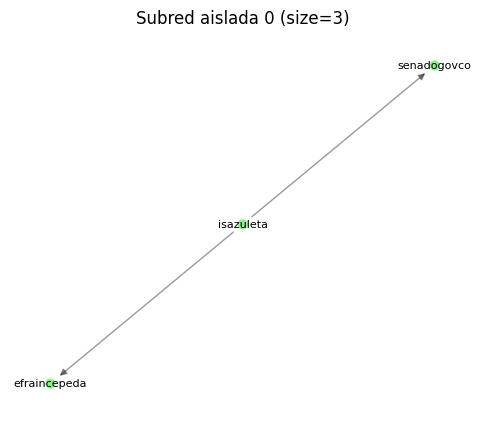

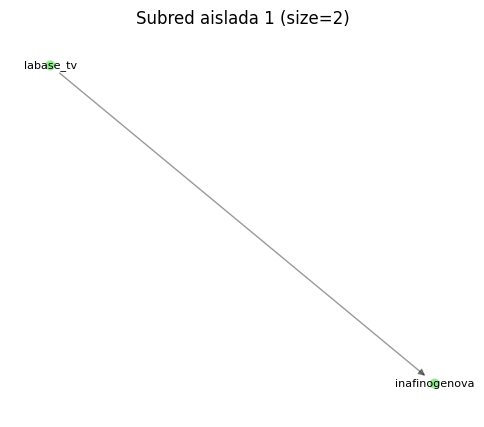

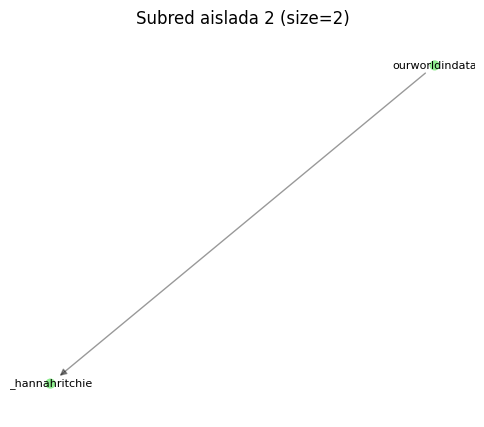

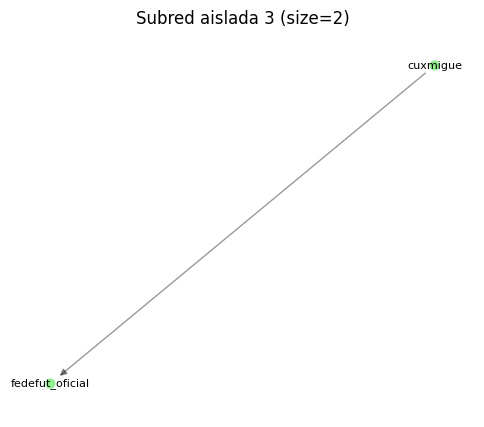

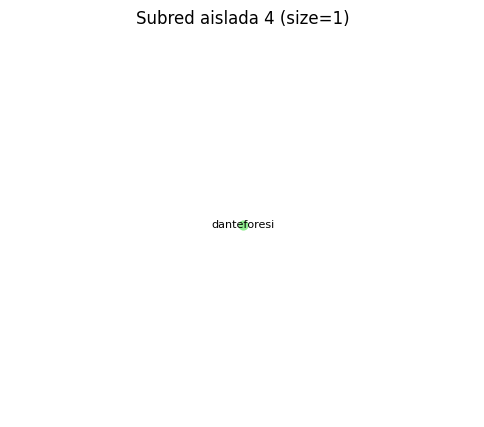

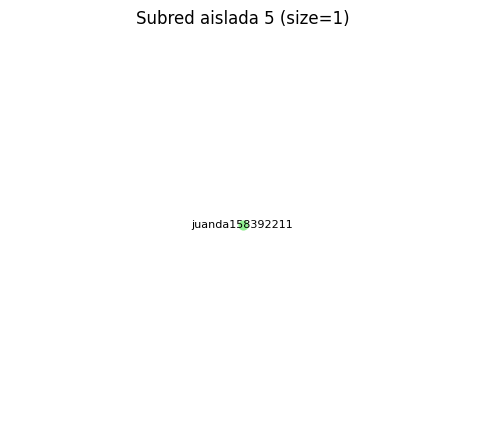

Muestra de nodos aislados (hasta 50):


['danteforesi',
 'juanda158392211',
 'betocoralg',
 'osarguatemala1',
 'dondieg28700696',
 'mayrado57466678',
 'monerorictus',
 'captercio',
 'ma_wukong',
 'infogt_noticias',
 'eddymcano',
 'joshuajcip',
 'soymemegt',
 'don_kamu',
 'fiaheisenberg',
 'amazlngnature',
 'adikraj1',
 'socerezagirasol',
 'arteymas_',
 'bee_dlee',
 'bvoluntariosgt',
 'agustinromm',
 'kaminaljuyu_vz7',
 'an0nymousgtd',
 'fuedicho',
 'aneudy_n',
 'david_qva',
 'cesargarcia0293',
 'mipais100',
 'yoeldeleon23']

In [55]:
GRAPH_FILE = "data/graph_tioberny_simple.gexf"
CSV_FILE = "data/clean_tioberny_v3.csv"

if os.path.exists(GRAPH_FILE):
    G = nx.read_gexf(GRAPH_FILE)
else:
    df = pd.read_csv(CSV_FILE)
    def _extract_rt_username(rt):
        if pd.isna(rt): return None
        try:
            obj = json.loads(rt) if isinstance(rt, str) else rt
            if isinstance(obj, dict):
                u = obj.get("user") or {}
                return u.get("username") or obj.get("username")
        except:
            s = str(rt)
            m = re.search(r'"username"\s*:\s*"([^"]+)"', s)
            if m: return m.group(1)
        return None
    G = nx.DiGraph()
    for _, row in df.iterrows():
        src = row.get("username")
        if pd.isna(src): continue
        src = str(src).lower().strip()
        if src == "": continue
        if not G.has_node(src): G.add_node(src)
        mentioned = row.get("mentioned_users")
        if pd.notna(mentioned) and str(mentioned).strip() != "":
            for tgt in str(mentioned).split(","):
                tgt = tgt.strip().lower()
                if tgt == "" or tgt == src: continue
                if G.has_edge(src, tgt):
                    G[src][tgt]["weight"] = G[src][tgt].get("weight", 0) + 1
                else:
                    G.add_edge(src, tgt, weight=1, type="mention")
        in_reply = row.get("in_reply_to_username")
        if pd.notna(in_reply) and str(in_reply).strip() != "":
            tgt = str(in_reply).strip().lower()
            if tgt != "" and tgt != src:
                if G.has_edge(src, tgt):
                    G[src][tgt]["weight"] = G[src][tgt].get("weight", 0) + 1
                else:
                    G.add_edge(src, tgt, weight=1, type="reply")
        rt_user = _extract_rt_username(row.get("retweeted_tweet"))
        if rt_user:
            tgt = str(rt_user).lower().strip()
            if tgt != "" and tgt != src:
                if G.has_edge(src, tgt):
                    G[src][tgt]["weight"] = G[src][tgt].get("weight", 0) + 1
                else:
                    G.add_edge(src, tgt, weight=1, type="retweet")

ug = G.to_undirected()
components = sorted(nx.connected_components(ug), key=len, reverse=True)
comp_sizes = [len(c) for c in components]
df_comp = pd.DataFrame({"component_id": list(range(len(components))), "size": comp_sizes})
display(df_comp.head(50))
plt.figure(figsize=(8,4))
pd.Series(comp_sizes).value_counts().sort_index().plot(kind="bar")
plt.xlabel("Tamaño de componente")
plt.ylabel("Cantidad de componentes")
plt.title("Distribución de tamaños de componentes conectados")
plt.show()
isolated_nodes = [n for n,d in dict(G.degree()).items() if d == 0]
print("Número de nodos aislados:", len(isolated_nodes))
small_groups = [c for c in components if len(c) <= 10]
summary_rows = []
for i, comp in enumerate(components[:20]):
    sub = G.subgraph(comp)
    summary_rows.append({
        "component_id": i,
        "size": sub.number_of_nodes(),
        "edges": sub.number_of_edges(),
        "density": nx.density(sub.to_undirected()) if sub.number_of_nodes()>1 else 0.0,
        "avg_degree": sum(dict(sub.degree()).values())/max(1, sub.number_of_nodes())
    })
df_summary = pd.DataFrame(summary_rows)
display(df_summary)
to_plot = small_groups[:6]
for i, comp in enumerate(to_plot):
    sub = G.subgraph(comp).copy()
    if sub.number_of_nodes() == 0: continue
    plt.figure(figsize=(6,5))
    pos = nx.spring_layout(sub, k=0.3, iterations=50)
    deg = dict(sub.degree(weight="weight"))
    nx.draw_networkx_nodes(sub, pos, node_size=[max(40, deg.get(n,0)) for n in sub.nodes()], node_color="lightgreen")
    nx.draw_networkx_edges(sub, pos, alpha=0.4)
    labels = {n:n for n,_ in sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8]}
    nx.draw_networkx_labels(sub, pos, labels, font_size=8)
    plt.title(f"Subred aislada {i} (size={sub.number_of_nodes()})")
    plt.axis("off")
    plt.show()
print("Muestra de nodos aislados (hasta 50):")
display(isolated_nodes[:50])

## Análisis de contenido y sentimiento

,count
sentiment_label,
neutral,4729
negativo,111
positivo,104


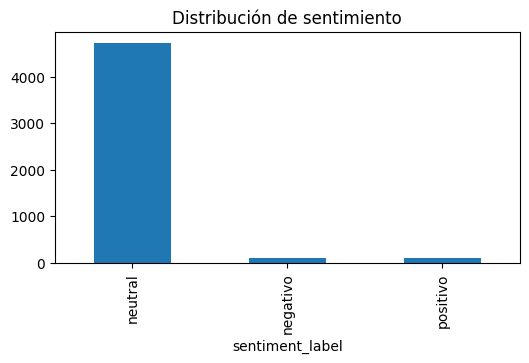

,topic_id,top_terms
0,0,"[ubaldomacu, santipalomov, mpguatemala, santip..."
1,1,"[barevalodeleon, olsenpsico, olsenpsico bareva..."
2,2,"[diariodeca, fjimenezmingob, pncdeguatemala, _..."
3,3,"[__vadertg, __vadertg barevalodeleon, barevalo..."
4,4,"[elquenews, bancadasemilla, barevalodeleon avi..."
5,5,"[guatemalagob, guatemalagob barevalodeleon, ba..."


Usuario: barevalodeleon
Tema 1: peso 0.012 -> barevalodeleon, olsenpsico, olsenpsico barevalodeleon, ivanduque, ivanduque barevalodeleon, presidente, gersongudielcas, gersongudielcas barevalodeleon
Tema 5: peso 0.007 -> guatemalagob, guatemalagob barevalodeleon, barevalodeleon, barevalodeleon guatemalagob, barevalodeleon felixsinexcusas, felixsinexcusas, rafaelae1967, karinherreravp viceguatemala
Tema 4: peso 0.006 -> elquenews, bancadasemilla, barevalodeleon avillagran502, bancadasemilla barevalodeleon, avillagran502, elquenews barevalodeleon, elquenews bancadasemilla, barevalodeleon fjimenezmingob
Tema 0: peso 0.003 -> ubaldomacu, santipalomov, mpguatemala, santipalomov barevalodeleon, ubaldomacu mpguatemala, mpguatemala santipalomov, ubaldomacu barevalodeleon, barevalodeleon santipalomov
Tema 3: peso 0.001 -> __vadertg, __vadertg barevalodeleon, barevalodeleon usaidguate, usaidguate congresoguate, usaidguate, congresoguate, oco_motora, oco_motora __vadertg


,comm_id,n_members,n_tweets,top_topics
0,0,1019,1232,"[(1, [barevalodeleon, olsenpsico, olsenpsico b..."
1,1,542,754,"[(1, [barevalodeleon, olsenpsico, olsenpsico b..."
2,2,468,849,"[(0, [ubaldomacu, santipalomov, mpguatemala, s..."
3,3,369,863,"[(4, [elquenews, bancadasemilla, barevalodeleo..."
4,4,329,754,"[(2, [diariodeca, fjimenezmingob, pncdeguatema..."
5,5,222,307,"[(3, [__vadertg, __vadertg barevalodeleon, bar..."
6,6,34,63,"[(5, [guatemalagob, guatemalagob barevalodeleo..."
7,7,11,4,"[(1, [barevalodeleon, olsenpsico, olsenpsico b..."
8,8,10,1,"[(1, [barevalodeleon, olsenpsico, olsenpsico b..."
9,9,10,14,"[(5, [guatemalagob, guatemalagob barevalodeleo..."


In [61]:
CSV_FILE = "data/clean_tioberny_v3.csv"
GEXF_FILE = "data/graph_tioberny_simple.gexf"
USER_TARGET = "barevalodeleon"
df = pd.read_csv(CSV_FILE)
texts = df["raw_content"].fillna("").astype(str)
try:
    nlp = spacy.load("es_core_news_sm")
    nlp.add_pipe("spacytextblob")
    polarity = texts.apply(lambda t: nlp(t)._.polarity if t.strip()!="" else 0.0)
    subjectivity = texts.apply(lambda t: nlp(t)._.subjectivity if t.strip()!="" else 0.0)
except Exception:
    try:
        polarity = texts.apply(lambda t: TextBlob(t).sentiment.polarity if t.strip()!="" else 0.0)
        subjectivity = texts.apply(lambda t: TextBlob(t).sentiment.subjectivity if t.strip()!="" else 0.0)
    except Exception:
        pos_lex = {"bien","bueno","excelente","feliz","contento","positivo","ganó","gracias","apoyo","favor"}
        neg_lex = {"malo","mal","pésimo","odio","triste","negativo","perdió","pena","corrupto","odio"}
        def lex_sent(t):
            toks = re.findall(r"\w+", t.lower())
            if not toks: return 0.0, 0.0
            pos = sum(1 for w in toks if w in pos_lex)
            neg = sum(1 for w in toks if w in neg_lex)
            score = (pos - neg) / max(1, len(toks))
            subj = (pos + neg) / max(1, len(toks))
            return score, subj
        res = texts.apply(lambda t: lex_sent(t))
        polarity = res.apply(lambda x: x[0])
        subjectivity = res.apply(lambda x: x[1])

df["sentiment_polarity"] = polarity
df["sentiment_subjectivity"] = subjectivity
df["sentiment_label"] = df["sentiment_polarity"].apply(lambda v: "positivo" if v>0.05 else ("negativo" if v<-0.05 else "neutral"))
display(pd.DataFrame(df["sentiment_label"].value_counts()).rename(columns={"sentiment_label":"count"}))
plt.figure(figsize=(6,3))
df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Distribución de sentimiento")
plt.show()

stopwords = [] # Initialize as an empty list
try:
    nlp2 = spacy.load("es_core_news_sm")
    stopwords = list(nlp2.Defaults.stop_words) # Convert set to list
except:
    stopwords = ["y","que","lo","la","e","de","no","el","a","los","en"] # Keep as list

vectorizer = TfidfVectorizer(max_features=4000, stop_words=stopwords, ngram_range=(1,2))
X = vectorizer.fit_transform(texts)
n_topics = 6
nmf = NMF(n_components=n_topics, random_state=42, init='random', solver='cd') # Specify solver and init
W = nmf.fit_transform(X)
H = nmf.components_
terms = vectorizer.get_feature_names_out()
topic_terms = []
for i, comp in enumerate(H):
    terms_idx = np.argsort(comp)[-15:][::-1]
    topic_terms.append([terms[t] for t in terms_idx])
df_topics = pd.DataFrame({"topic_id": list(range(len(topic_terms))), "top_terms": topic_terms})
display(df_topics)

user = USER_TARGET.lower().lstrip("@")
df_user = df[df["username"].fillna("").astype(str).str.lower()==user]
if df_user.shape[0] > 0:
    X_user = vectorizer.transform(df_user["raw_content"].fillna("").astype(str))
    W_user = nmf.transform(X_user)
    user_topic_weights = W_user.sum(axis=0)
    user_topic_rank = sorted(list(enumerate(user_topic_weights)), key=lambda x: x[1], reverse=True)
    print("Usuario:", user)
    for tid, val in user_topic_rank[:5]:
        print(f"Tema {tid}: peso {val:.3f} ->", ", ".join(topic_terms[tid][:8]))
else:
    print("No se encontraron tweets para el usuario:", user)

if os.path.exists(GEXF_FILE):
    G = nx.read_gexf(GEXF_FILE)
    ug = G.to_undirected()
    communities = list(nx_comm.greedy_modularity_communities(ug))
    comm_summary = []
    for i, comm in enumerate(communities):
        members = set(comm)
        df_comm = df[df["username"].fillna("").astype(str).str.lower().isin(members)]
        if df_comm.shape[0] == 0:
            comm_summary.append((i, len(members), 0, []))
            continue
        Xc = vectorizer.transform(df_comm["raw_content"].fillna("").astype(str))
        Wc = nmf.transform(Xc)
        topic_weights = Wc.sum(axis=0)
        top_topics = sorted(list(enumerate(topic_weights)), key=lambda x: x[1], reverse=True)[:3]
        top_topics_readable = [(t, topic_terms[t][:6]) for t,_ in top_topics]
        comm_summary.append((i, len(members), df_comm.shape[0], top_topics_readable))
    df_comm_summary = pd.DataFrame(comm_summary, columns=["comm_id","n_members","n_tweets","top_topics"])
    display(df_comm_summary.sort_values("n_members", ascending=False).head(10))
else:
    print("No hay grafo para relacionar comunidades con temas")